In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [2]:
train_df = pd.read_csv('../data/train.csv')

In [3]:
train_df = pd.read_csv('../data/train.csv')

def clean_running_column(df, column_name='running'):
    def convert(val):
        val = val.lower().replace(',', '').strip()
        if 'km' in val:
            return float(val.replace('km', '').strip())
        elif 'miles' in val:
            miles = float(val.replace('miles', '').strip())
            return round(miles * 1.60934, 2)
        return np.nan
    
    df['running_km'] = df[column_name].apply(convert)
    return df

def add_car_age(df, year_col='year', current_year=2025):
    df['car_age'] = current_year - df[year_col].astype(int)
    return df

def conver_to_numeric(df):
    df['motor_volume'] = pd.to_numeric(df['motor_volume'], errors='coerce')
    return df

In [4]:
train_df = clean_running_column(train_df)
train_df = add_car_age(train_df)
train_df = conver_to_numeric(train_df)

label_cols = ['model', 'motor_type', 'wheel', 'color', 'type', 'status']
encoders = {}

for col in label_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    encoders[col] = le

train_df.dropna(inplace=True)

In [5]:
features = ['model', 'motor_type', 'wheel', 'color', 'type', 'status', 'motor_volume', 'running_km', 'car_age']
target = 'price'

x_train = train_df[features]
y_train = train_df[target]

In [6]:
model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
test_df = pd.read_csv('../data/test.csv')

test_df = clean_running_column(test_df)
test_df = add_car_age(test_df)
test_df = conver_to_numeric(test_df)

for col, le in encoders.items():
    if col in test_df.columns:
        test_df[col] = test_df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

In [8]:
x_test = test_df[features]

predictions = model.predict(x_test)
rounded_preds = predictions.round().astype(int)

output_df = pd.DataFrame({
    'Id': x_test.index,
    'price': rounded_preds
})

output_df.to_csv('../outputs/xgboost_predictions.csv', index=False)

X = train_df[features]
y = train_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

evaluation_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
evaluation_model.fit(X_train, y_train)

y_pred = evaluation_model.predict(X_val)

📊 Model Evaluation Metrics
✅ Mean Absolute Error (MAE):      2,130.24
✅ Root Mean Squared Error (RMSE): 3,654.39
✅ R² Score:                       0.6965


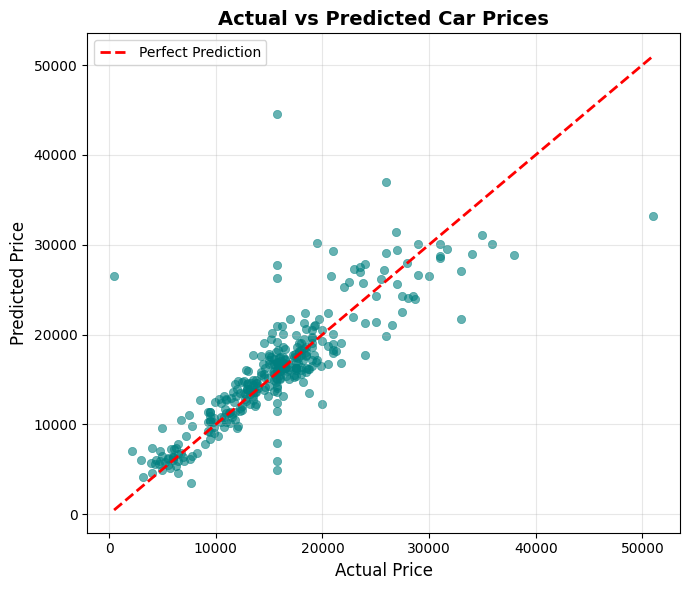

C:\Users\chanuth_w\AppData\Local\Temp\ipykernel_32060\1277304470.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_brands, x='model', y='count', palette="mako", legend=False)


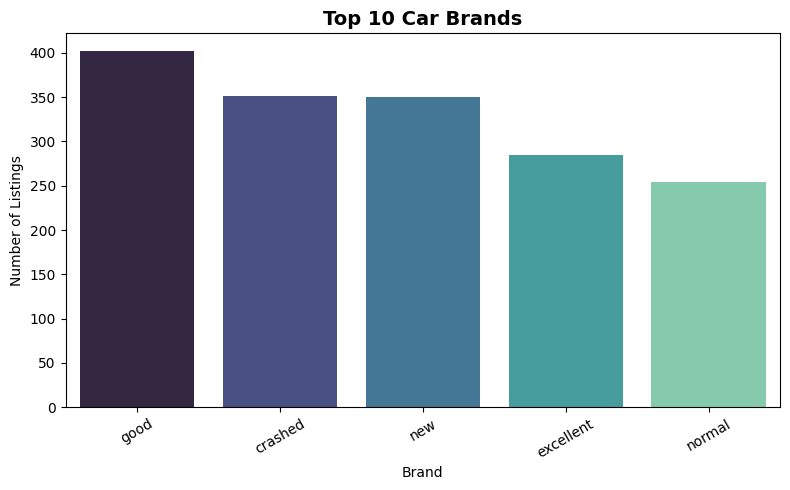

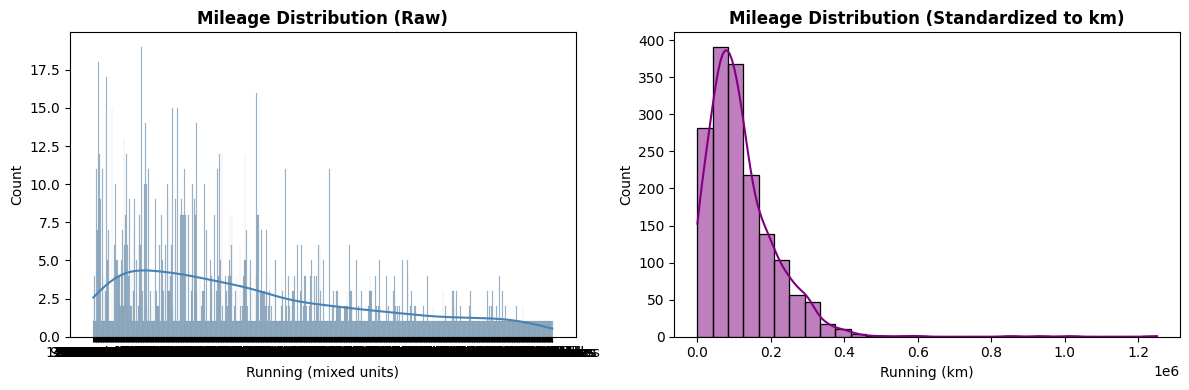

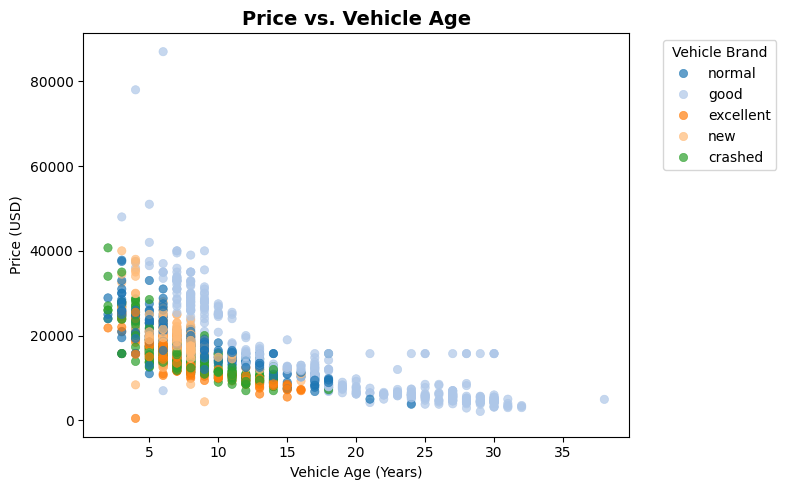

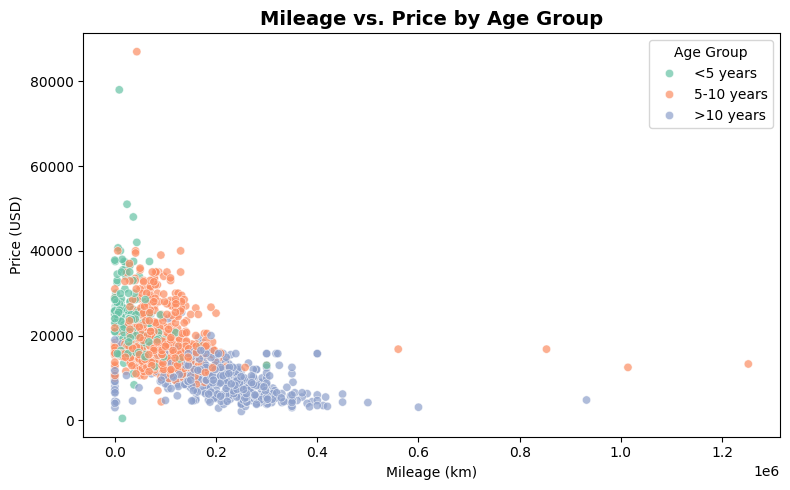

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------- Metric Functions ----------
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def display_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("📊 Model Evaluation Metrics")
    print("=" * 40)
    print(f"✅ Mean Absolute Error (MAE):      {mae:,.2f}")
    print(f"✅ Root Mean Squared Error (RMSE): {rmse:,.2f}")
    print(f"✅ R² Score:                       {r2:,.4f}")
    print("=" * 40)
    
    return mae, rmse, r2

# ---------- Evaluation ----------
mae, rmse, r2 = display_metrics(y_val, y_pred)

# ---------- Plot: Actual vs Predicted ----------
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.6, edgecolor=None, color="teal")
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label="Perfect Prediction")
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Actual vs Predicted Car Prices", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Load Encoders ----------
encoders = joblib.load("../models/encoders.pkl")
model_encoder = encoders['model']

train_df['model_name'] = model_encoder.inverse_transform(train_df['model'])

# ---------- Plot: Top Car Brands ----------
plt.figure(figsize=(8, 5))
top_brands = train_df['model_name'].value_counts().head(10).reset_index()
top_brands.columns = ['model', 'count']
sns.barplot(data=top_brands, x='model', y='count', palette="mako", legend=False)
plt.title("Top 10 Car Brands", fontsize=14, fontweight="bold")
plt.ylabel("Number of Listings")
plt.xlabel("Brand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------- Plot: Mileage Distribution (Raw & Standardized) ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df['running'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title("Mileage Distribution (Raw)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Running (mixed units)")

sns.histplot(train_df['running_km'], bins=30, kde=True, color='purple', ax=axes[1])
axes[1].set_title("Mileage Distribution (Standardized to km)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Running (km)")

plt.tight_layout()
plt.show()

# ---------- Plot: Price vs Vehicle Age ----------
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df, 
    x='car_age', 
    y='price', 
    hue='model_name',
    palette='tab20',
    alpha=0.7,
    edgecolor=None
)
plt.title("Price vs. Vehicle Age", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Price (USD)")
plt.legend(title="Vehicle Brand", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------- Plot: Mileage vs Price by Age Group ----------
train_df['age_group'] = pd.cut(
    train_df['car_age'], 
    bins=[0, 5, 10, 50], 
    labels=['<5 years', '5-10 years', '>10 years']
)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df, 
    x='running_km', 
    y='price', 
    hue='age_group', 
    palette='Set2',
    alpha=0.7
)
plt.title("Mileage vs. Price by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (USD)")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()
